# Paper scaling figure from benchmark 03

This notebook is plotting-only. It reads the latest CSV written by `03_knottedgraph_vs_topoly_scaling.ipynb`; it does not run KnottedGraph or Topoly Yamada computations.

The layout follows the earlier publication-template idea: panel **(a)** is a four-column KnottedGraph/Plotly display block with 3D embeddings, 2D projection diagrams, and PD-code snippets; panels **(b)**-**(e)** are four separate runtime-scaling panels built from the same CSV. Rows are de-duplicated by `(benchmark, case_key)`, and the latest row in the CSV is used.

Run with the visualization extra enabled, for example:

```bash
uv run --extra viz --group docs python dev/execute_notebook.py User_guide/benchmarks/06_paper_scaling_publication_figure.ipynb
```


In [22]:
from __future__ import annotations

import copy
import csv
import json
import math
import sys
from collections import Counter
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from matplotlib.lines import Line2D
from PIL import Image
from plotly.subplots import make_subplots


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "knotted_graph").exists():
            return candidate
    raise RuntimeError("Could not find the KnottedGraph repository root from the current directory")


ROOT = find_repo_root()
SRC = ROOT / "src"
DEV = ROOT / "dev"
for path in (SRC, DEV):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from knotted_graph.projection import PDCode  # noqa: E402
from knotted_graph.visualization import plot_3D_graph_plotly  # noqa: E402
from benchmark_dobrynin_vesnin_theta_family import theta_family_graph  # noqa: E402
from benchmark_lllv_edge_replacement import build_replaced_graph  # noqa: E402

BENCHMARK_DIR = ROOT / "User_guide" / "benchmarks"
RESULTS_CSV = BENCHMARK_DIR / "results" / "03_knottedgraph_vs_topoly_scaling_rows.csv"
FIGURE_DIR = BENCHMARK_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

KG_COLOR = "#2F5FB3"
TOPOLY_COLOR = "#111111"
ERROR_COLOR = "#C1121F"
VERTEX_COLOR = "#A60628"

PANEL_LABEL_FONT_SIZE = 36
AXIS_LABEL_FONT_SIZE = 30
TICK_FONT_SIZE = 24
LEGEND_FONT_SIZE = 20
AXIS_LINE_WIDTH = 1.9
SERIES_LINE_WIDTH = 3.2
MARKER_SIZE = 8.5
NONPASS_MARKER_SIZE = 130

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "figure.dpi": 220,
    "font.size": 18,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "axes.linewidth": AXIS_LINE_WIDTH,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": AXIS_LINE_WIDTH,
    "ytick.major.width": AXIS_LINE_WIDTH,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "savefig.facecolor": "white",
})

print("Repository:", ROOT)
print("CSV:", RESULTS_CSV)
print("Figures:", FIGURE_DIR)


Repository: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2
CSV: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/results/03_knottedgraph_vs_topoly_scaling_rows.csv
Figures: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures


In [23]:
# User-adjustable plotting extent. These are filters for the CSV, not commands
# to run missing benchmarks. Missing rows are reported and skipped.

THETA_N_VALUES = list(range(0, 30))+[50,100,200,300,400,500]  
LLLV_CYCLE_N_VALUES = list(range(3, 30))+[50,100,200,300,400,500]
LLLV_THETA_S_VALUES = list(range(3, 30))+[50,100,200,300,400,500]


THETA_N_VALUES = list(range(0, 30))
LLLV_CYCLE_N_VALUES = list(range(3, 30))
LLLV_THETA_S_VALUES = list(range(3, 30))

# Use exact top-row examples for panel (a). Set a value to None to
# automatically use the largest available row in the latest CSV.
PANEL_A_SIZE_OVERRIDES = {
    "dv_theta": 6,
    "lllv_cycle": 9,
    "lllv_theta": 6,
}

FIGURE_BASENAME = "06_paper_scaling_from_03_csv"
TOP_WORKFLOW_BASENAME = f"{FIGURE_BASENAME}_panel_a_3d_workflow"
SCALING_BASENAME = f"{FIGURE_BASENAME}_scaling_1x3"

# Display controls inherited from the old paper-figure template.
PD_FONT_SIZE = 30
PD_CODE_MAX_CHARS = 108
UNDER_GAP_FRACTION = 0.18
FIRST_ROW_PANEL_Y_SHIFT = 0.025
FIRST_ROW_GRAPH_UP_SHIFT = 0.0
FIRST_ROW_3D_ZOOM = 1.0
FIRST_ROW_FIGURE_SCALE = 0.98
SECOND_ROW_FIGURE_SCALE = 1.08
ROW1_ROW2_GAP = -0.045
PD_CODE_BELOW_PROJECTION_GAP = 0.020
PD_CODE_BLOCK_HEIGHT = 0.190
BOTTOM_BORDER_BELOW_PD_GAP = 0.022
REMOVE_OUTER_BOTTOM_GAP = True
OUTER_BOTTOM_GAP_AFTER_CROP = 0.0
SECOND_ROW_PROJECTION_PADDING = 0.055
SECOND_ROW_EXTRA_TOP_PADDING = 0.060
PANEL_A_COLUMN_X_SHIFTS = (0.15, 0.000, -0.15)
# Final-figure panel label placement. Negative shift moves all (a)-(d) labels left.
PANEL_LABEL_X_INSET = 0.040
PANEL_LABEL_X_SHIFT = -0.035

# Separate interactive Plotly checks for the selected panel (a) examples.
SHOW_PANEL_A_INTERACTIVE = True
WRITE_PANEL_A_INTERACTIVE_HTML = True
PANEL_A_INTERACTIVE_WIDTH = 1120
PANEL_A_INTERACTIVE_HEIGHT = 560
PANEL_A_COLOR_LLLV_REPLACEMENTS = True
LLLV_REPLACEMENT_COLORS = {
    "edge": "#2F5FB3",
    "loop_bead": "#1B9E77",
    "theta_bead": "#D95F02",
    "twist_bead": "#7570B3",
    "twist_bead_mirror": "#E7298A",
}
PDF_DPI = 700
PNG_DPI = 450

print("DV Theta values:", THETA_N_VALUES)
print("LLLV cycle values:", LLLV_CYCLE_N_VALUES)
print("LLLV theta values:", LLLV_THETA_S_VALUES)


DV Theta values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
LLLV cycle values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
LLLV theta values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [24]:
NUMERIC_COLUMNS = {
    "size", "n", "V", "E", "crossings", "extra_projection_crossings",
    "knottedgraph_s", "topoly_s", "topoly_over_knottedgraph",
    "case_wall_s", "timeout_s",
}


def to_float(value):
    if value is None or value == "":
        return math.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def to_int(value, default=None):
    number = to_float(value)
    if math.isfinite(number):
        return int(number)
    return default


def finite_positive(value) -> bool:
    number = to_float(value)
    return math.isfinite(number) and number > 0


def read_latest_results(csv_path: Path) -> list[dict]:
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing {csv_path}; run notebook 03 first.")
    with csv_path.open(newline="") as handle:
        raw = list(csv.DictReader(handle))
    for index, row in enumerate(raw):
        row["_row_order"] = index
        for column in NUMERIC_COLUMNS:
            if column in row:
                row[column] = to_float(row[column])
    latest = {}
    for row in raw:
        latest[(row.get("benchmark", ""), row.get("case_key", ""))] = row
    return sorted(latest.values(), key=lambda row: row["_row_order"])


def print_table(rows: list[dict], columns: list[tuple[str, str]]) -> None:
    widths = []
    for key, label in columns:
        values = [len(str(row.get(key, ""))) for row in rows]
        widths.append(max([len(label), *values]))
    print(" | ".join(label.ljust(width) for (_, label), width in zip(columns, widths)))
    print("-+-".join("-" * width for width in widths))
    for row in rows:
        print(" | ".join(str(row.get(key, "")).ljust(width) for (key, _), width in zip(columns, widths)))


results = read_latest_results(RESULTS_CSV)
print(f"Loaded {len(results)} latest rows from {RESULTS_CSV.name}")
for graph_type, count in sorted(Counter(row.get("graph_type", "") for row in results).items()):
    print(f"{graph_type:>14}: {count}")

FAMILY_SPECS = [
    {
        "key": "dv_theta",
        "title": "DV Theta(n)",
        "panel_title": r"DV $\Theta(n)$",
        "graph_types": ["dv_handcuff", "dv_theta"],
        "sizes": THETA_N_VALUES,
        "x_label": r"$n$",
        "kind": "dv",
    },
    {
        "key": "lllv_cycle",
        "title": "LLLV C_n",
        "panel_title": r"LLLV $C_n$",
        "graph_types": ["cycle"],
        "sizes": LLLV_CYCLE_N_VALUES,
        "x_label": r"$n$",
        "kind": "lllv",
    },
    {
        "key": "lllv_theta",
        "title": "LLLV Theta_s",
        "panel_title": r"LLLV $\Theta_s$",
        "graph_types": ["theta"],
        "sizes": LLLV_THETA_S_VALUES,
        "x_label": r"$s$",
        "kind": "lllv",
    },
]


def rows_for_family(spec: dict) -> list[dict]:
    allowed = {int(value) for value in spec["sizes"]}
    by_size = {}
    for row in results:
        size = to_int(row.get("size"))
        if row.get("graph_type") in spec["graph_types"] and size in allowed:
            by_size[size] = row
    return [by_size[size] for size in sorted(by_size)]


family_frames = {spec["key"]: rows_for_family(spec) for spec in FAMILY_SPECS}
coverage_rows = []
for spec in FAMILY_SPECS:
    frame = family_frames[spec["key"]]
    expected = [int(value) for value in spec["sizes"]]
    observed = sorted(to_int(row.get("size")) for row in frame)
    missing = [value for value in expected if value not in set(observed)]
    coverage_rows.append({
        "family": spec["title"],
        "selected": len(expected),
        "rows_in_csv": len(observed),
        "largest_in_csv": max(observed) if observed else "",
        "missing_sizes": ", ".join(map(str, missing)) if missing else "",
    })

print_table(
    coverage_rows,
    [("family", "family"), ("selected", "selected"), ("rows_in_csv", "rows in CSV"), ("largest_in_csv", "largest in CSV"), ("missing_sizes", "missing sizes")],
)


Loaded 118 latest rows from 03_knottedgraph_vs_topoly_scaling_rows.csv
       bouquet: 27
         cycle: 28
   dv_handcuff: 21
      dv_theta: 15
         theta: 27
family       | selected | rows in CSV | largest in CSV | missing sizes
-------------+----------+-------------+----------------+--------------
DV Theta(n)  | 30       | 30          | 29             |              
LLLV C_n     | 27       | 27          | 29             |              
LLLV Theta_s | 27       | 27          | 29             |              


In [25]:
def parse_pieces(value) -> tuple[str, ...]:
    if isinstance(value, (list, tuple)):
        return tuple(str(item) for item in value)
    if not isinstance(value, str) or not value.strip():
        return ()
    return tuple(str(item) for item in json.loads(value))


def graph_for_row(spec: dict, row: dict) -> nx.MultiGraph:
    if spec["kind"] == "dv":
        return theta_family_graph(to_int(row.get("size"), 0))
    return build_replaced_graph(str(row.get("graph_type", "")), parse_pieces(row.get("pieces", "")))


def select_panel_a_row(spec: dict, frame: list[dict]) -> dict:
    if not frame:
        raise RuntimeError(f"No CSV rows available for {spec['title']}")
    override = PANEL_A_SIZE_OVERRIDES.get(spec["key"])
    if override is not None:
        for row in frame:
            if to_int(row.get("size")) == int(override):
                return row
        raise RuntimeError(f"Requested panel-a size {override} for {spec['title']} is not in the CSV")
    return sorted(frame, key=lambda row: (to_int(row.get("size"), -1), row.get("_row_order", -1)))[-1]


def display_label(spec: dict, row: dict) -> str:
    size = to_int(row.get("size"), "?")
    if spec["key"] == "dv_theta":
        return f"DV Theta({size})"
    if spec["key"] == "lllv_cycle":
        return f"LLLV C_{size}"
    if spec["key"] == "lllv_theta":
        return f"LLLV Theta_{size}"
    return str(row.get("label") or spec["title"])


def display_normalized_copy(graph: nx.MultiGraph) -> nx.MultiGraph:
    display_graph = copy.deepcopy(graph)
    geometry = []
    for _, data in display_graph.nodes(data=True):
        if "pos" in data:
            geometry.append(np.asarray(data["pos"], dtype=float))
    for _, _, _, data in display_graph.edges(keys=True, data=True):
        if "pts" in data:
            geometry.extend(np.asarray(data["pts"], dtype=float))
    if not geometry:
        return display_graph
    points = np.vstack(geometry)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    center = 0.5 * (lower + upper)
    span = np.maximum(upper - lower, 1e-12)
    target_extent = 3.60
    # Display-only presentation scaling: use one scalar scale factor.  This
    # preserves the geometry of mostly planar LLLV replacement graphs instead
    # of exaggerating their small z-depth into artificial vertical structures.
    scale = target_extent / float(np.max(span))

    def transform(points):
        points = np.asarray(points, dtype=float)
        return (points - center) * scale

    for _, data in display_graph.nodes(data=True):
        if "pos" in data:
            data["pos"] = transform(data["pos"])
    for _, _, _, data in display_graph.edges(keys=True, data=True):
        if "pts" in data:
            data["pts"] = transform(data["pts"])
    return display_graph


def graph_has_replacement_pieces(graph: nx.MultiGraph) -> bool:
    return any("replacement_piece" in data for _, _, _, data in graph.edges(keys=True, data=True))


def replacement_piece_name(data: dict) -> str:
    piece = data.get("replacement_piece")
    if isinstance(piece, (list, tuple)) and piece:
        return str(piece[-1])
    if piece is not None:
        return str(piece)
    return str(data.get("role") or "edge")


def replacement_piece_color(name: str) -> str:
    if PANEL_A_COLOR_LLLV_REPLACEMENTS:
        return LLLV_REPLACEMENT_COLORS.get(name, KG_COLOR)
    return KG_COLOR


def edge_points(graph: nx.MultiGraph, left, right, data: dict) -> np.ndarray:
    if "pts" in data:
        return np.asarray(data["pts"], dtype=float)
    return np.asarray([graph.nodes[left]["pos"], graph.nodes[right]["pos"]], dtype=float)


def add_replacement_geometry_3d_traces(figure, graph, *, row, col, show_piece_legend: bool = False):
    shown = set()
    for left, right, _key, data in graph.edges(keys=True, data=True):
        pts = edge_points(graph, left, right, data)
        name = replacement_piece_name(data)
        color = replacement_piece_color(name)
        showlegend = bool(show_piece_legend and name not in shown)
        shown.add(name)
        figure.add_trace(
            go.Scatter3d(
                x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
                mode="lines",
                line=dict(color=color, width=6.0),
                name=name, legendgroup=name, showlegend=showlegend,
                hovertemplate=(
                    f"piece: {name}<br>role: {data.get('role', '')}<br>"
                    f"edge: {left} -> {right}<extra></extra>"
                ),
            ),
            row=row, col=col,
        )
    node_xyz = []
    node_text = []
    for node, data in graph.nodes(data=True):
        if "pos" in data:
            node_xyz.append(np.asarray(data["pos"], dtype=float))
            node_text.append(str(node))
    if node_xyz:
        node_xyz = np.vstack(node_xyz)
        figure.add_trace(
            go.Scatter3d(
                x=node_xyz[:, 0], y=node_xyz[:, 1], z=node_xyz[:, 2],
                mode="markers",
                marker=dict(color=VERTEX_COLOR, size=6.5),
                name="vertices", showlegend=False, text=node_text,
                hovertemplate="vertex: %{text}<extra></extra>",
            ),
            row=row, col=col,
        )


def add_knottedgraph_traces(figure, graph, *, row, col, show_piece_legend: bool = False):
    if graph_has_replacement_pieces(graph):
        add_replacement_geometry_3d_traces(
            figure, graph, row=row, col=col, show_piece_legend=show_piece_legend
        )
        return
    kg_figure = plot_3D_graph_plotly(graph)
    for trace in kg_figure.data:
        if getattr(trace, "type", None) == "scatter3d":
            mode = getattr(trace, "mode", "") or ""
            line = getattr(trace, "line", None)
            line_color = str(getattr(line, "color", "") or "").lower().replace(" ", "")
            is_box_trace = "lines" in mode and line_color in {"black", "#000", "#000000", "rgb(0,0,0)", "rgba(0,0,0,1)"}
            if is_box_trace and line is not None:
                trace.line.width = max(float(getattr(trace.line, "width", 0) or 0), 2.2)
                trace.line.color = "black"
            elif "lines" in mode and line is not None:
                trace.line.width = max(float(getattr(trace.line, "width", 0) or 0), 6.0)
            if "markers" in mode and getattr(trace, "marker", None) is not None:
                trace.marker.size = max(float(getattr(trace.marker, "size", 0) or 0), 6.0)
        figure.add_trace(trace, row=row, col=col)

def under_arc_ids_by_crossing(processor):
    result = {}
    for crossing_id, crossing in processor.crossings.items():
        ordered = list(crossing.ccw_ordered_arcs)
        result[crossing_id] = {ordered[1], ordered[3]} if len(ordered) == 4 else set()
    return result


def projection_display_transform(processor):
    xy = []
    for arc in processor.arcs.values():
        coords = np.asarray(arc.line.coords, dtype=float)
        xy.append(coords[:, :2])
    if not xy:
        return lambda pts: np.asarray(pts, dtype=float)[:, :2]
    points = np.vstack(xy)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    center = 0.5 * (lower + upper)
    span = np.maximum(upper - lower, 1e-12)
    if SECOND_ROW_FIGURE_SCALE <= 0:
        raise ValueError("SECOND_ROW_FIGURE_SCALE must be positive")
    scale = SECOND_ROW_FIGURE_SCALE / float(np.max(span))

    def transform(pts):
        pts = np.asarray(pts, dtype=float)[:, :2]
        return (pts - center) * scale

    return transform


def graph_geometry_2d_transform(graph: nx.MultiGraph):
    xy = []
    for _, data in graph.nodes(data=True):
        if "pos" in data:
            xy.append(np.asarray(data["pos"], dtype=float)[None, :2])
    for left, right, _key, data in graph.edges(keys=True, data=True):
        xy.append(edge_points(graph, left, right, data)[:, :2])
    if not xy:
        return lambda pts: np.asarray(pts, dtype=float)[:, :2]
    points = np.vstack(xy)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    center = 0.5 * (lower + upper)
    span = np.maximum(upper - lower, 1e-12)
    scale = SECOND_ROW_FIGURE_SCALE / float(np.max(span))

    def transform(pts):
        pts = np.asarray(pts, dtype=float)[:, :2]
        return (pts - center) * scale

    return transform


def add_replacement_geometry_2d_traces(figure, graph, *, row, col, show_piece_legend: bool = False):
    transform = graph_geometry_2d_transform(graph)
    shown = set()
    for left, right, _key, data in graph.edges(keys=True, data=True):
        pts = transform(edge_points(graph, left, right, data))
        name = replacement_piece_name(data)
        color = replacement_piece_color(name)
        showlegend = bool(show_piece_legend and name not in shown)
        shown.add(name)
        figure.add_trace(
            go.Scatter(
                x=pts[:, 0], y=pts[:, 1], mode="lines",
                line=dict(color=color, width=4.2),
                name=name, legendgroup=name, showlegend=showlegend,
                hovertemplate=(
                    f"piece: {name}<br>role: {data.get('role', '')}<br>"
                    f"edge: {left} -> {right}<extra></extra>"
                ),
            ),
            row=row, col=col,
        )
    node_xy = []
    node_text = []
    for node, data in graph.nodes(data=True):
        if "pos" in data:
            node_xy.append(transform(np.asarray(data["pos"], dtype=float)[None, :])[0])
            node_text.append(str(node))
    if node_xy:
        node_xy = np.vstack(node_xy)
        figure.add_trace(
            go.Scatter(
                x=node_xy[:, 0], y=node_xy[:, 1], mode="markers",
                marker=dict(color=VERTEX_COLOR, size=10.5),
                name="vertices", showlegend=False, text=node_text,
                hovertemplate="vertex: %{text}<extra></extra>",
            ),
            row=row, col=col,
        )


def under_arc_ids_by_crossing(processor):
    result = {}
    for crossing_id, crossing in processor.crossings.items():
        ordered = list(crossing.ccw_ordered_arcs)
        result[crossing_id] = {ordered[1], ordered[3]} if len(ordered) == 4 else set()
    return result


def projection_arc_xy(arc, under_by_crossing, transform):
    coords = np.asarray(arc.line.coords, dtype=float).copy()
    if len(coords) < 2:
        return transform(coords)
    start_is_under = arc.start_type == "x" and arc.id in under_by_crossing.get(arc.start_id, set())
    end_is_under = arc.end_type == "x" and arc.id in under_by_crossing.get(arc.end_id, set())
    if start_is_under:
        coords[0] = coords[0] + UNDER_GAP_FRACTION * (coords[1] - coords[0])
    if end_is_under:
        coords[-1] = coords[-1] + UNDER_GAP_FRACTION * (coords[-2] - coords[-1])
    return transform(coords)


def add_projection_traces(figure, processor, *, row, col, graph: nx.MultiGraph | None = None, show_piece_legend: bool = False):
    if graph is not None and graph_has_replacement_pieces(graph):
        add_replacement_geometry_2d_traces(
            figure, graph, row=row, col=col, show_piece_legend=show_piece_legend
        )
        return
    under_by_crossing = under_arc_ids_by_crossing(processor)
    transform = projection_display_transform(processor)
    for arc in processor.arcs.values():
        xy = projection_arc_xy(arc, under_by_crossing, transform)
        figure.add_trace(
            go.Scatter(x=xy[:, 0], y=xy[:, 1], mode="lines", line=dict(color=KG_COLOR, width=3.8), hoverinfo="skip", showlegend=False),
            row=row, col=col,
        )
    if processor.vertices:
        vertex_xy = np.array([[vertex.point.x, vertex.point.y] for vertex in processor.vertices.values()])
        vertex_xy = transform(vertex_xy)
        figure.add_trace(
            go.Scatter(x=vertex_xy[:, 0], y=vertex_xy[:, 1], mode="markers", marker=dict(color=VERTEX_COLOR, size=10), hoverinfo="skip", showlegend=False),
            row=row, col=col,
        )
    if processor.crossings:
        crossing_xy = np.array([[crossing.point.x, crossing.point.y] for crossing in processor.crossings.values()])
        crossing_xy = transform(crossing_xy)
        figure.add_trace(
            go.Scatter(x=crossing_xy[:, 0], y=crossing_xy[:, 1], mode="markers", marker=dict(color="black", size=4), hoverinfo="skip", showlegend=False),
            row=row, col=col,
        )

def split_balanced(text: str, n_lines: int = 3) -> str:
    text = str(text)
    if n_lines < 1:
        raise ValueError("n_lines must be >= 1")
    length = len(text)
    base = length // n_lines
    extra = length % n_lines
    parts = []
    start = 0
    for i in range(n_lines):
        width = base + (1 if i < extra else 0)
        parts.append(text[start:start + width])
        start += width
    return "<br>".join(parts)


def pd_display_text(pd_code: str) -> str:
    text = str(pd_code)
    suffix = "..." if len(text) > PD_CODE_MAX_CHARS else ""
    shown = text[:PD_CODE_MAX_CHARS]
    return split_balanced(shown, n_lines=3) + suffix


def build_record(spec: dict, row: dict) -> dict:
    graph = graph_for_row(spec, row)
    processor = PDCode(graph)
    pd_code = processor.compute(rotation_angles=(0.0, 0.0, 0.0), rotation_order="ZYX")
    return {
        "spec": spec,
        "row": row,
        "graph": graph,
        "display_graph": display_normalized_copy(graph),
        "processor": processor,
        "pd_code": pd_code,
        "pd_text": pd_display_text(pd_code),
        "label": display_label(spec, row),
    }


present_specs = [spec for spec in FAMILY_SPECS if family_frames[spec["key"]]]
if len(present_specs) != 3:
    raise RuntimeError(f"Expected three nonempty families for the paper figure; found {len(present_specs)}")

records = [build_record(spec, select_panel_a_row(spec, family_frames[spec["key"]])) for spec in present_specs]
print_table(
    [{"panel": chr(ord("a") + i), "family": rec["spec"]["title"], "label": rec["label"], "pd_chars": len(str(rec["pd_code"]))} for i, rec in enumerate(records)],
    [("panel", "panel"), ("family", "family"), ("label", "shown graph"), ("pd_chars", "PD chars")],
)


panel | family       | shown graph  | PD chars
------+--------------+--------------+---------
a     | DV Theta(n)  | DV Theta(6)  | 93      
b     | LLLV C_n     | LLLV C_6     | 141     
c     | LLLV Theta_s | LLLV Theta_6 | 129     


In [26]:
def make_panel_domains(n: int, *, margin: float = 0.006, gap: float = 0.012) -> list[tuple[float, float]]:
    width = (1.0 - 2.0 * margin - (n - 1) * gap) / n
    return [(margin + i * (width + gap), margin + i * (width + gap) + width) for i in range(n)]


def remap_paper_y(y, old_bottom, new_bottom=0.0):
    if y is None:
        return y
    return new_bottom + (float(y) - old_bottom) * (1.0 - new_bottom) / (1.0 - old_bottom)


def remove_outer_bottom_paper_gap(fig, crop_y0, keep_gap=0.0, *, ncols: int):
    crop_y0 = float(crop_y0)
    keep_gap = float(keep_gap)
    for index in range(1, ncols + 1):
        scene_name = "scene" if index == 1 else f"scene{index}"
        scene = getattr(fig.layout, scene_name, None)
        if scene is not None and scene.domain is not None and scene.domain.y is not None:
            y0, y1 = scene.domain.y
            scene.domain.y = [remap_paper_y(y0, crop_y0, keep_gap), remap_paper_y(y1, crop_y0, keep_gap)]
        axis_name = "yaxis" if index == 1 else f"yaxis{index}"
        axis = getattr(fig.layout, axis_name, None)
        if axis is not None and axis.domain is not None:
            y0, y1 = axis.domain
            axis.domain = [remap_paper_y(y0, crop_y0, keep_gap), remap_paper_y(y1, crop_y0, keep_gap)]
    for annotation in fig.layout.annotations or ():
        if getattr(annotation, "yref", None) == "paper":
            annotation.y = remap_paper_y(annotation.y, crop_y0, keep_gap)
    for shape in fig.layout.shapes or ():
        if getattr(shape, "yref", None) == "paper":
            shape.y0 = remap_paper_y(shape.y0, crop_y0, keep_gap)
            shape.y1 = remap_paper_y(shape.y1, crop_y0, keep_gap)
    return fig


ncols = len(records)
workflow_fig = make_subplots(
    rows=2, cols=ncols,
    specs=[[{"type": "scene"} for _ in range(ncols)], [{"type": "xy"} for _ in range(ncols)]],
    horizontal_spacing=0.008,
    vertical_spacing=0.004,
    row_heights=[0.64, 0.36],
)

for col, record in enumerate(records, start=1):
    add_projection_traces(workflow_fig, record["processor"], graph=record["graph"], row=2, col=col)
for col, record in enumerate(records, start=1):
    add_knottedgraph_traces(workflow_fig, record["display_graph"], row=1, col=col)

panel_domains = make_panel_domains(ncols)


# Keep Plotly subplot domains fixed; large horizontal shifts are applied to the
# rendered panel-a image later so shifted columns remain clipped to their boxes.
panel_content_domains = panel_domains
FIRST_ROW_BASE_Y0 = 0.460
FIRST_ROW_BASE_Y1 = 0.972
first_row_height = FIRST_ROW_BASE_Y1 - FIRST_ROW_BASE_Y0
requested_first_row_y0 = FIRST_ROW_BASE_Y0 + FIRST_ROW_PANEL_Y_SHIFT
requested_first_row_y1 = requested_first_row_y0 + first_row_height
if requested_first_row_y1 > 1.0:
    first_row_y1 = 1.0
    first_row_y0 = 1.0 - first_row_height
elif requested_first_row_y0 < 0.0:
    first_row_y0 = 0.0
    first_row_y1 = first_row_height
else:
    first_row_y0 = requested_first_row_y0
    first_row_y1 = requested_first_row_y1

if FIRST_ROW_3D_ZOOM <= 0 or FIRST_ROW_FIGURE_SCALE <= 0:
    raise ValueError("FIRST_ROW_3D_ZOOM and FIRST_ROW_FIGURE_SCALE must be positive")
first_row_scene_half_range = 2.18
effective_first_row_camera_zoom = 1.30 * FIRST_ROW_3D_ZOOM * FIRST_ROW_FIGURE_SCALE

def default_first_row_camera(effective_zoom):
    return dict(
        eye=dict(x=0.35 / effective_zoom, y=0.35 / effective_zoom, z=0.40 / effective_zoom),
        center=dict(x=0.00, y=0.02, z=-0.06 - FIRST_ROW_GRAPH_UP_SHIFT),
        up=dict(x=0.0, y=0.0, z=1.0),
        projection=dict(type="orthographic"),
    )

for index, (x0, x1) in enumerate(panel_content_domains, start=1):
    scene_name = "scene" if index == 1 else f"scene{index}"
    workflow_fig.update_layout(**{scene_name: dict(
        domain=dict(x=[x0, x1], y=[first_row_y0, first_row_y1]),
        xaxis=dict(visible=False, range=[-first_row_scene_half_range, first_row_scene_half_range], showticklabels=False, title="", showgrid=False, zeroline=False, showspikes=False, showbackground=False, backgroundcolor="rgba(255,255,255,0)", showline=False, linecolor="rgba(0,0,0,0)", linewidth=0),
        yaxis=dict(visible=False, range=[-first_row_scene_half_range, first_row_scene_half_range], showticklabels=False, title="", showgrid=False, zeroline=False, showspikes=False, showbackground=False, backgroundcolor="rgba(255,255,255,0)", showline=False, linecolor="rgba(0,0,0,0)", linewidth=0),
        zaxis=dict(visible=False, range=[-first_row_scene_half_range, first_row_scene_half_range], showticklabels=False, title="", showgrid=False, zeroline=False, showspikes=False, showbackground=False, backgroundcolor="rgba(255,255,255,0)", showline=False, linecolor="rgba(0,0,0,0)", linewidth=0),
        aspectmode="cube",
        bgcolor="rgba(0,0,0,0)",
        camera=default_first_row_camera(effective_first_row_camera_zoom),
    )})

base_projection_half_range = 0.5 * SECOND_ROW_FIGURE_SCALE + SECOND_ROW_PROJECTION_PADDING
SECOND_ROW_BASE_Y0 = 0.135
SECOND_ROW_BASE_Y1 = 0.435
second_row_height = SECOND_ROW_BASE_Y1 - SECOND_ROW_BASE_Y0
requested_second_row_y0 = SECOND_ROW_BASE_Y0
requested_second_row_y1 = SECOND_ROW_BASE_Y1
second_row_y1 = first_row_y0 - ROW1_ROW2_GAP
second_row_y0 = second_row_y1 - second_row_height
if second_row_y0 < 0.0:
    second_row_y0 = requested_second_row_y0
    second_row_y1 = requested_second_row_y1

for index, (x0, x1) in enumerate(panel_content_domains, start=1):
    xaxis_name = "xaxis" if index == 1 else f"xaxis{index}"
    yaxis_name = "yaxis" if index == 1 else f"yaxis{index}"
    y_min = -base_projection_half_range
    y_max = base_projection_half_range + SECOND_ROW_EXTRA_TOP_PADDING
    workflow_fig.update_layout(**{
        xaxis_name: dict(domain=[x0, x1], range=[-base_projection_half_range, base_projection_half_range], visible=False, fixedrange=True),
        yaxis_name: dict(domain=[second_row_y0, second_row_y1], range=[y_min, y_max], visible=False, fixedrange=True, scaleanchor=("x" if index == 1 else f"x{index}"), scaleratio=1),
    })

pd_code_y = second_row_y0 - PD_CODE_BELOW_PROJECTION_GAP
for (x0, x1), record in zip(panel_content_domains, records):
    workflow_fig.add_annotation(
        x=(x0 + x1) / 2, y=pd_code_y, xref="paper", yref="paper",
        text=record["pd_text"], showarrow=False, xanchor="center", yanchor="top", align="center",
        font=dict(family="Courier New, monospace", size=PD_FONT_SIZE, color="black"),
    )

border_y0 = max(0.001, min(pd_code_y - PD_CODE_BLOCK_HEIGHT - BOTTOM_BORDER_BELOW_PD_GAP, 0.998))
if REMOVE_OUTER_BOTTOM_GAP:
    remove_outer_bottom_paper_gap(workflow_fig, crop_y0=border_y0, keep_gap=OUTER_BOTTOM_GAP_AFTER_CROP, ncols=ncols)

WORKFLOW_WIDTH = 2800
WORKFLOW_HEIGHT = 1420
workflow_fig.update_layout(
    width=WORKFLOW_WIDTH, height=WORKFLOW_HEIGHT, margin=dict(l=1, r=1, t=1, b=1),
    showlegend=False, font=dict(family="Times New Roman, Times, DejaVu Serif, serif", color="black"),
    paper_bgcolor="white", plot_bgcolor="white",
)

workflow_html = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}.html"
workflow_png = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}.png"
workflow_pdf = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}.pdf"
workflow_fig.write_html(workflow_html, include_plotlyjs="cdn")
workflow_fig.write_image(workflow_png, width=WORKFLOW_WIDTH, height=WORKFLOW_HEIGHT, scale=2)
workflow_fig.write_image(workflow_pdf, width=WORKFLOW_WIDTH, height=WORKFLOW_HEIGHT)
print("Saved:", workflow_html)
print("Saved:", workflow_png)
print("Saved:", workflow_pdf)


Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow.html
Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow.png
Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow.pdf


### Interactive panel (a) checks

Run the next cell to inspect each selected panel `(a)` example separately. Each Plotly figure shows the same rebuilt graph used in the static panel. For Li--Lei--Li--Vesnin examples, colors identify the generated replacement pieces: blue = `edge`, green = `loop_bead`, orange = `theta_bead`. These are generated theorem-test edge replacements, not literal reproductions of the paper figures.


In [ ]:
def build_panel_a_interactive_figure(record: dict, panel_index: int) -> go.Figure:
    label = record["label"]
    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "scene"}, {"type": "xy"}]],
        column_widths=[0.58, 0.42],
        horizontal_spacing=0.045,
        subplot_titles=(f"{label}: 3D embedding", "PD projection used"),
    )
    has_replacements = graph_has_replacement_pieces(record["graph"])
    add_knottedgraph_traces(fig, record["display_graph"], row=1, col=1, show_piece_legend=has_replacements)
    add_projection_traces(fig, record["processor"], graph=record["graph"], row=1, col=2, show_piece_legend=False)

    projection_half_range = base_projection_half_range
    fig.update_layout(
        title=dict(text=f"Panel (a{panel_index}) inspection - {label}", x=0.5),
        width=PANEL_A_INTERACTIVE_WIDTH,
        height=PANEL_A_INTERACTIVE_HEIGHT,
        showlegend=False,
        template="plotly_white",
        margin=dict(l=15, r=15, t=70, b=20),
        scene=dict(
            xaxis=dict(title="x", range=[-first_row_scene_half_range, first_row_scene_half_range]),
            yaxis=dict(title="y", range=[-first_row_scene_half_range, first_row_scene_half_range]),
            zaxis=dict(title="z", range=[-first_row_scene_half_range, first_row_scene_half_range]),
            aspectmode="cube",
            camera=default_first_row_camera(effective_first_row_camera_zoom),
        ),
    )
    fig.update_xaxes(
        title_text="projection x",
        range=[-projection_half_range, projection_half_range],
        constrain="domain",
        row=1,
        col=2,
    )
    fig.update_yaxes(
        title_text="projection y",
        range=[-projection_half_range, projection_half_range + SECOND_ROW_EXTRA_TOP_PADDING],
        scaleanchor="x",
        scaleratio=1,
        row=1,
        col=2,
    )
    return fig


panel_a_interactive_figures = []
for panel_index, record in enumerate(records, start=1):
    interactive_fig = build_panel_a_interactive_figure(record, panel_index)
    panel_a_interactive_figures.append(interactive_fig)
    if WRITE_PANEL_A_INTERACTIVE_HTML:
        html_path = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}_interactive_{panel_index}_{record['spec']['key']}.html"
        interactive_fig.write_html(html_path, include_plotlyjs="cdn")
        print("Saved interactive panel (a):", html_path)
    if SHOW_PANEL_A_INTERACTIVE:
        interactive_fig.show()


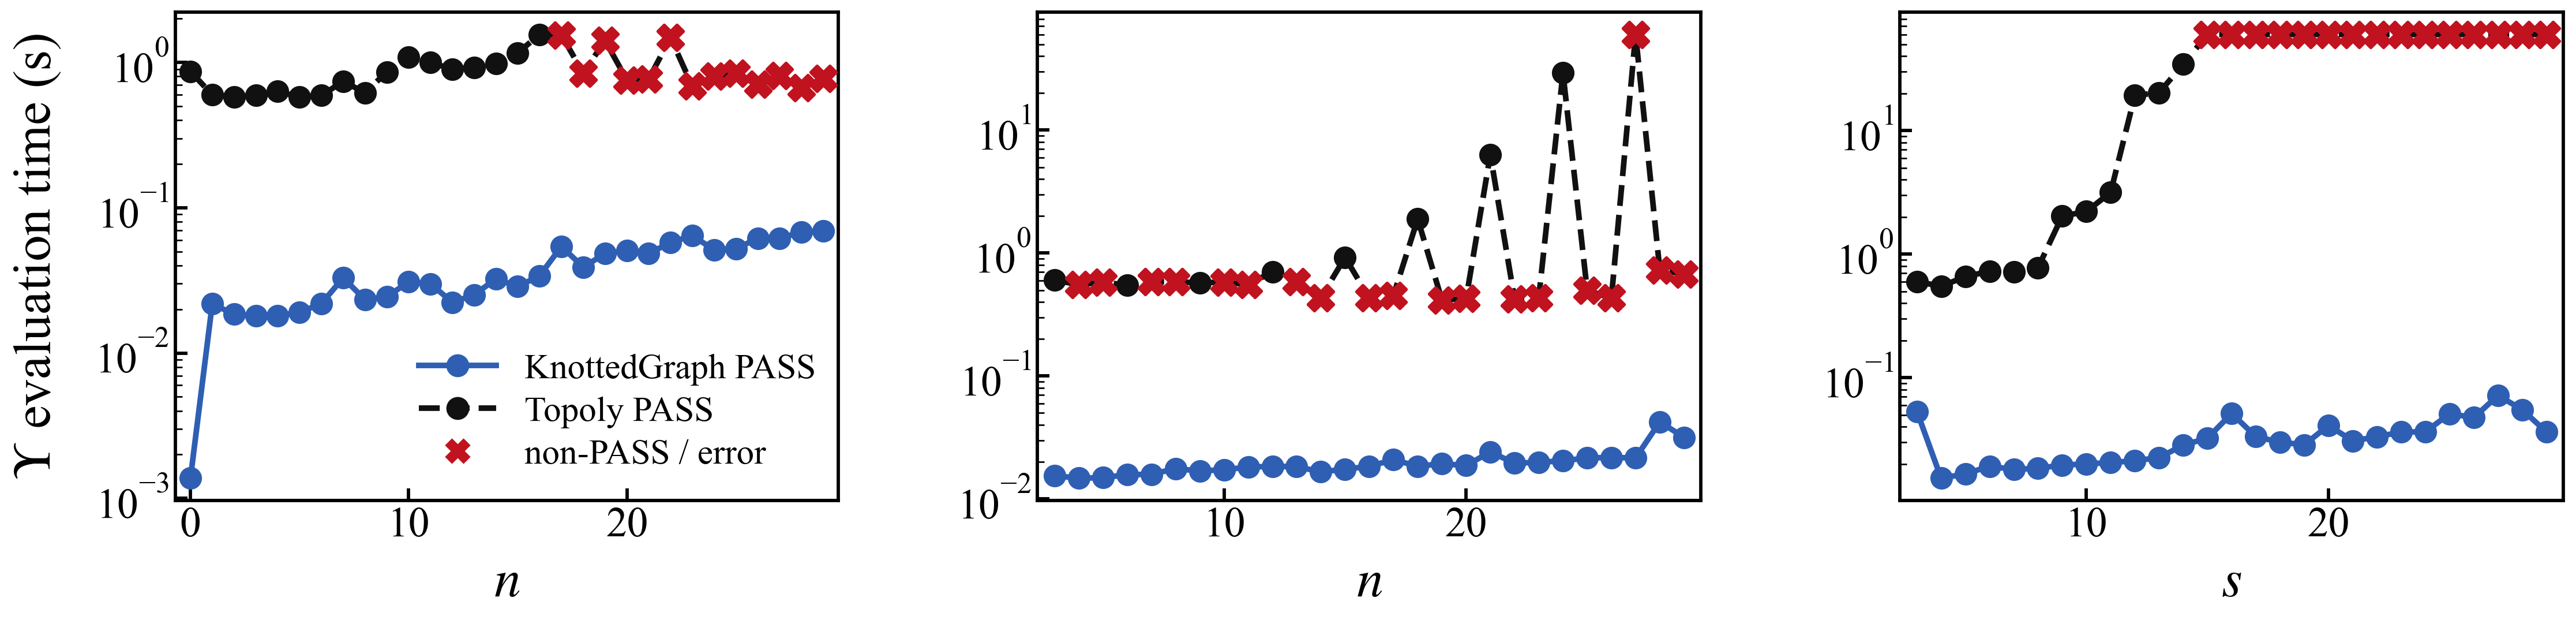

Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_scaling_1x3.pdf
Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_scaling_1x3.png


In [27]:
PASS_MARKER_SIZE = 135
NONPASS_MARKER_SIZE = 210
PASS_MARKER = "o"
NONPASS_MARKER = "X"
DRAW_SCALING_PANEL_LABELS = False


def result_is_pass(row: dict, framework: str) -> bool:
    """Interpret the CSV verdict columns: only literal PASS is correct."""
    result = str(row.get(f"{framework}_result", "")).strip().upper()
    if result:
        return result == "PASS"
    fallback_columns = (
        ("knottedgraph_vs_published", "knottedgraph_vs_theorem")
        if framework == "knottedgraph"
        else ("topoly_vs_published", "topoly_vs_theorem")
    )
    verdicts = [str(row.get(column, "")).strip().upper() for column in fallback_columns if str(row.get(column, "")).strip()]
    return bool(verdicts) and all(verdict == "PASS" for verdict in verdicts)


def finite_time_rows(frame: list[dict], time_column: str) -> list[dict]:
    return sorted(
        [row for row in frame if finite_positive(row.get(time_column))],
        key=lambda row: (to_int(row.get("size", -1)), row.get("_row_order", -1)),
    )


def style_axis(ax, *, panel_label: str, spec: dict, row_count: int):
    ax.set_yscale("log")
    ax.grid(False)
    ax.set_facecolor("white")
    ax.set_title("")
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(AXIS_LINE_WIDTH)
    ax.tick_params(which="major", top=False, right=False, labelsize=TICK_FONT_SIZE, width=AXIS_LINE_WIDTH, length=7, colors="black")
    ax.tick_params(which="minor", top=False, right=False, width=0.9, length=4, colors="black")
    ax.set_xlabel(spec["x_label"], labelpad=8)
    if DRAW_SCALING_PANEL_LABELS and panel_label:
        ax.text(
            -0.125, 1.045, panel_label,
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONT_SIZE,
            fontweight="bold",
            fontfamily="serif",
            color="black",
            ha="left",
            va="bottom",
            clip_on=False,
            zorder=20,
        )


def draw_timed_series(ax, rows: list[dict], *, framework: str, time_column: str, color: str, linestyle: str):
    if not rows:
        return
    x = np.array([to_int(row["size"]) for row in rows], dtype=float)
    y = np.array([to_float(row[time_column]) for row in rows], dtype=float)
    ok = np.array([result_is_pass(row, framework) for row in rows], dtype=bool)

    # Draw the scaling trend once, then give each point exactly one correctness marker.
    ax.plot(x, y, color=color, linestyle=linestyle, linewidth=SERIES_LINE_WIDTH, zorder=2)
    if ok.any():
        ax.scatter(
            x[ok], y[ok], marker=PASS_MARKER, s=PASS_MARKER_SIZE,
            facecolors=color, edgecolors=color, linewidths=1.2, zorder=4,
        )
    if (~ok).any():
        ax.scatter(
            x[~ok], y[~ok], marker=NONPASS_MARKER, s=NONPASS_MARKER_SIZE,
            color=ERROR_COLOR, linewidths=1.7, zorder=6,
        )


def draw_family_scaling(ax, spec: dict, frame: list[dict], *, panel_label: str):
    kg = finite_time_rows(frame, "knottedgraph_s")
    tp = finite_time_rows(frame, "topoly_s")
    draw_timed_series(ax, kg, framework="knottedgraph", time_column="knottedgraph_s", color=KG_COLOR, linestyle="-")
    draw_timed_series(ax, tp, framework="topoly", time_column="topoly_s", color=TOPOLY_COLOR, linestyle="--")
    observed = sorted(to_int(row.get("size")) for row in frame)
    if observed:
        ax.set_xlim(min(observed) - 0.7, max(observed) + 0.7)
    style_axis(ax, panel_label=panel_label, spec=spec, row_count=len(frame))


fig, axes = plt.subplots(1, 3, figsize=(21.0, 6.25), constrained_layout=False, facecolor="white")
for index, (ax, spec) in enumerate(zip(axes, FAMILY_SPECS)):
    draw_family_scaling(ax, spec, family_frames[spec["key"]], panel_label=f"({chr(ord('b') + index)})")
for ax in axes[1:]:
    ax.set_ylabel("")
axes[0].set_ylabel(r"$\Upsilon$ evaluation time (s)", labelpad=18)

legend_handles = [
    Line2D([0], [0], color=KG_COLOR, linestyle="-", marker=PASS_MARKER, markersize=12, linewidth=SERIES_LINE_WIDTH, label="KnottedGraph PASS"),
    Line2D([0], [0], color=TOPOLY_COLOR, linestyle="--", marker=PASS_MARKER, markersize=12, linewidth=SERIES_LINE_WIDTH, label="Topoly PASS"),
    Line2D([0], [0], color=ERROR_COLOR, linestyle="None", marker=NONPASS_MARKER, markersize=13, label="non-PASS / error"),
]
axes[0].legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(0.985, 0.035),
    fontsize=LEGEND_FONT_SIZE,
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="none",
    handlelength=2.2,
    borderpad=0.36,
    labelspacing=0.30,
    borderaxespad=0.0,
)
fig.subplots_adjust(left=0.100, right=0.996, top=0.825, bottom=0.210, wspace=0.30)

scaling_png = FIGURE_DIR / f"{SCALING_BASENAME}.png"
scaling_pdf = FIGURE_DIR / f"{SCALING_BASENAME}.pdf"
fig.savefig(scaling_pdf, dpi=PDF_DPI, bbox_inches="tight", pad_inches=0.08, facecolor="white", edgecolor="none")
fig.savefig(scaling_png, dpi=PNG_DPI, bbox_inches="tight", pad_inches=0.08, facecolor="white", edgecolor="none")
plt.show()
print("Saved:", scaling_pdf)
print("Saved:", scaling_png)


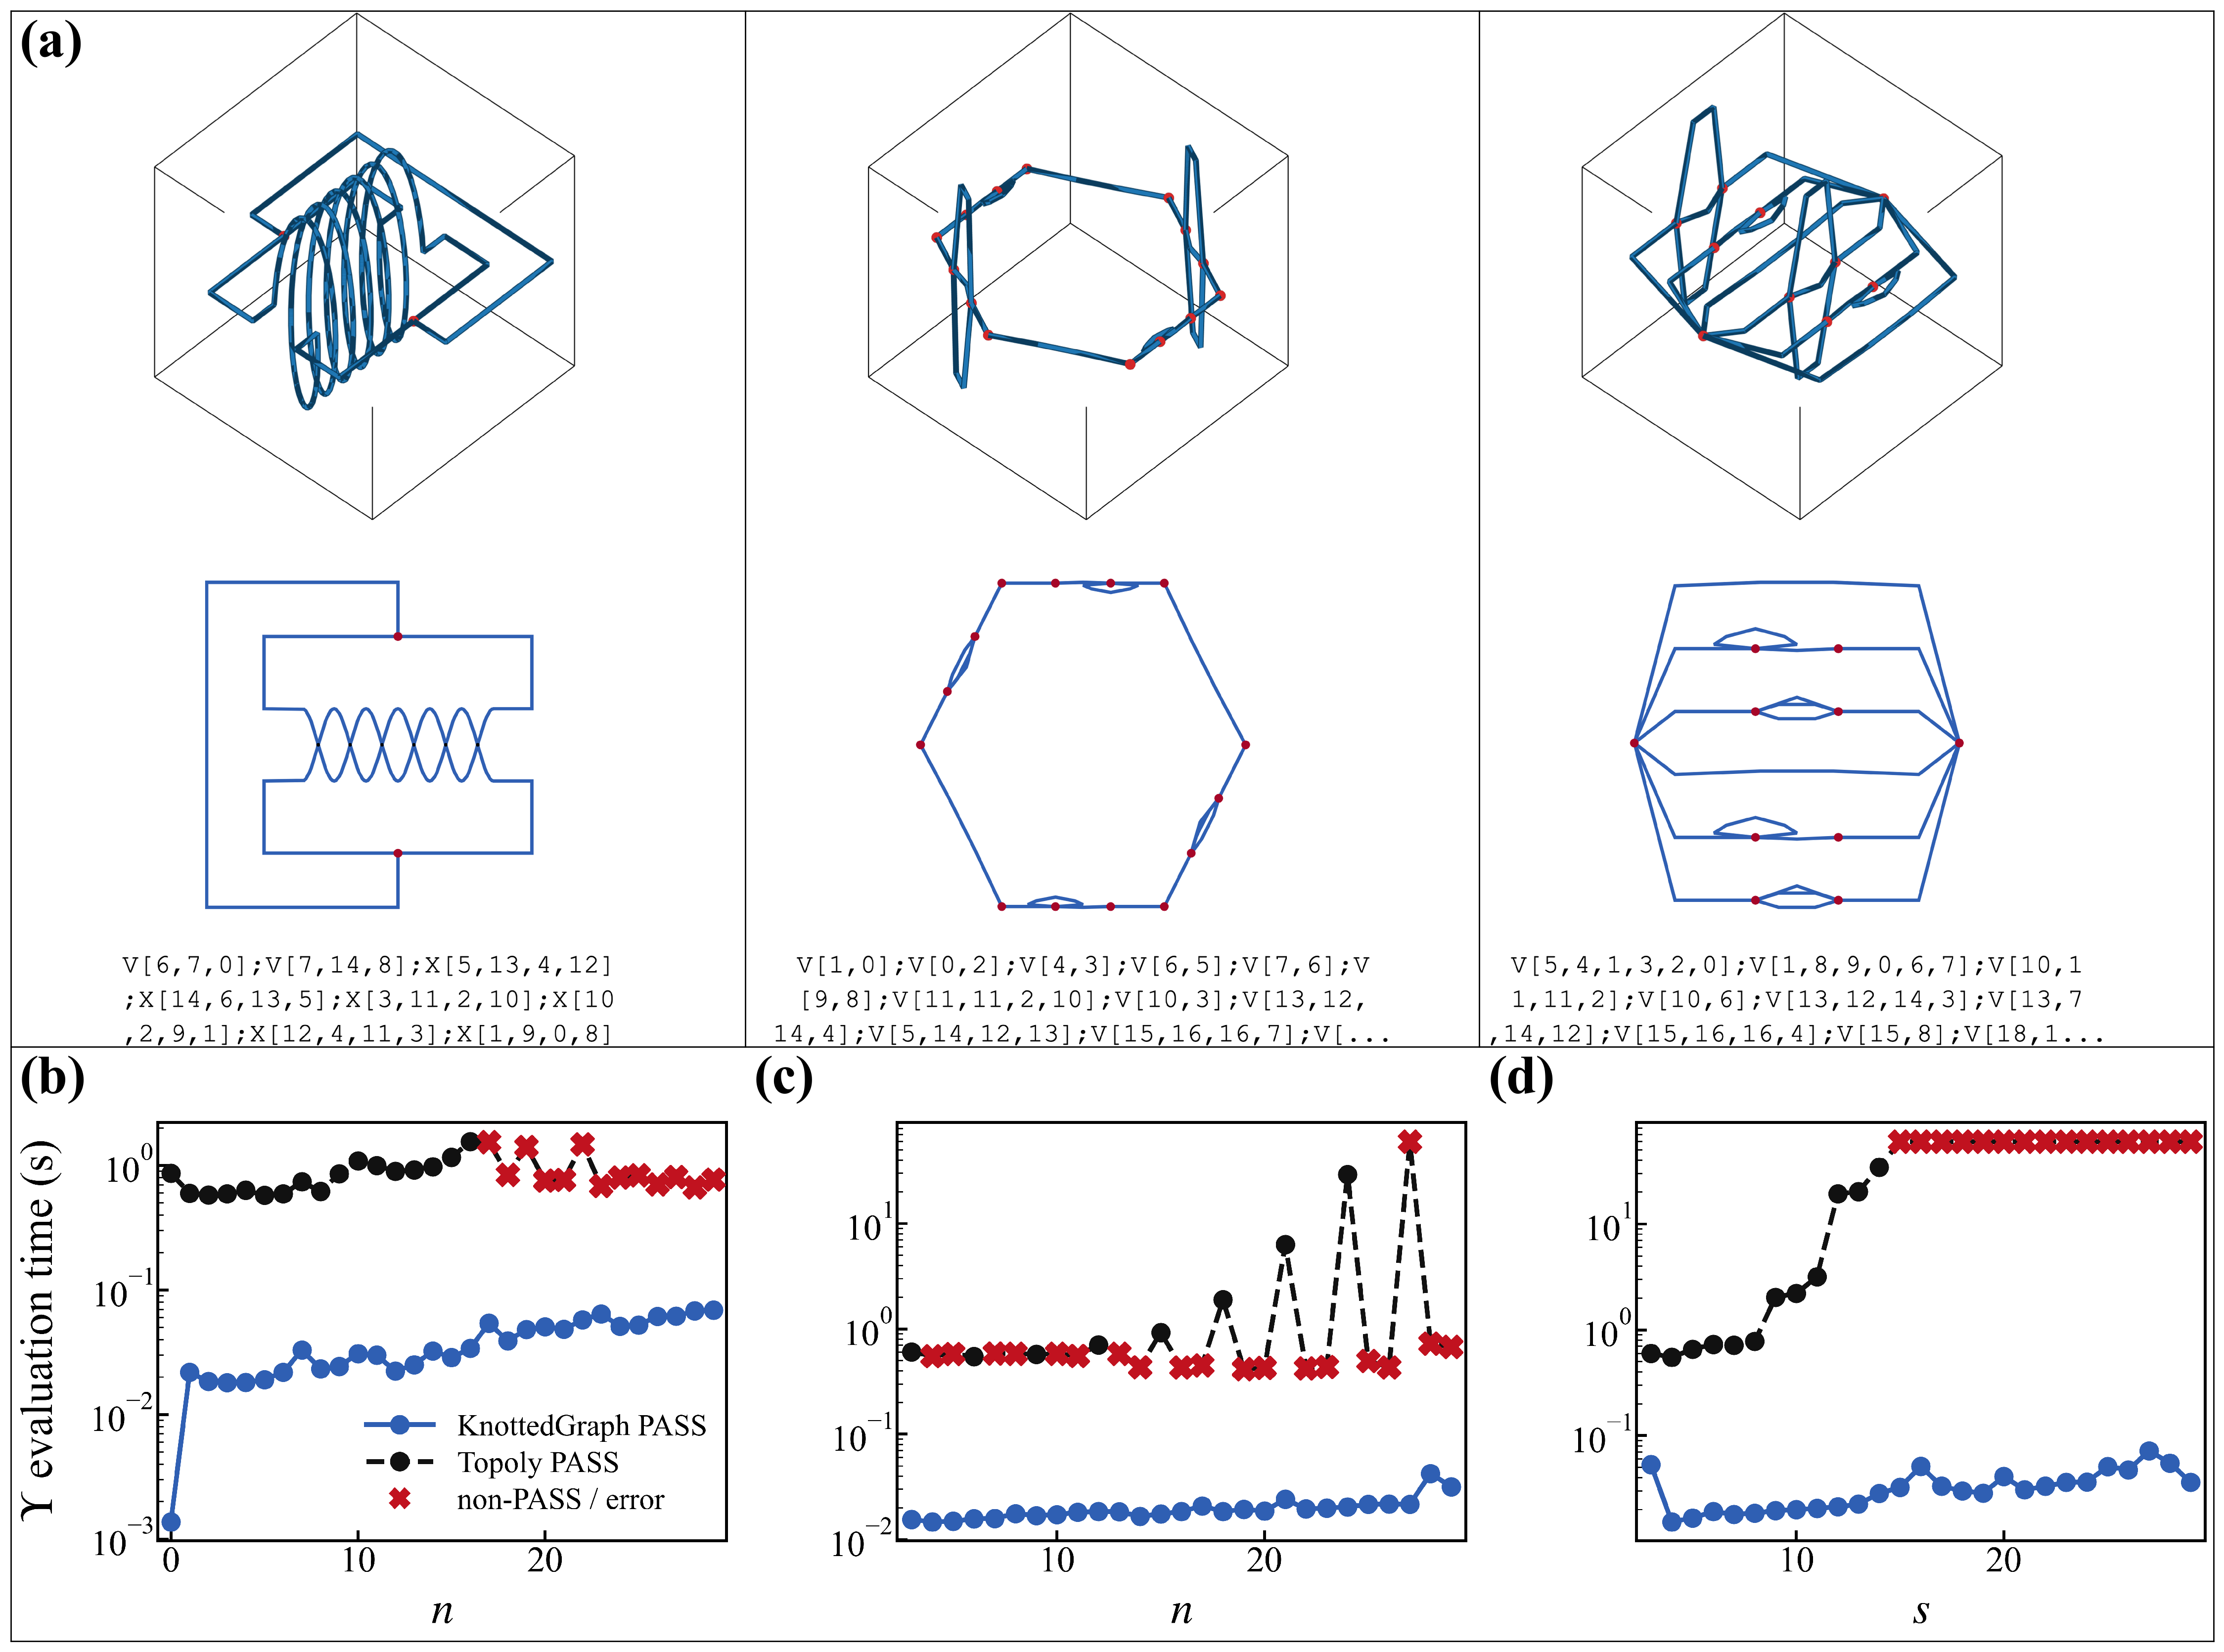

Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_two_row_combined.pdf
Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_two_row_combined.png
Saved legacy-compatible: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/topoly_vs_knottedgraph_two_row_combined.pdf
Saved legacy-compatible: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/KnottedGraph-perf-yamada-max-optimization-2/User_guide/benchmarks/figures/topoly_vs_knottedgraph_two_row_combined.png


In [28]:
def trim_white_margins(img, *, threshold=250, pad_px=3):
    arr = np.asarray(img)
    mask = np.any(arr < threshold, axis=2)
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    left = max(int(xs.min()) - pad_px, 0)
    right = min(int(xs.max()) + 1 + pad_px, img.width)
    top = max(int(ys.min()) - pad_px, 0)
    bottom = min(int(ys.max()) + 1 + pad_px, img.height)
    return img.crop((left, top, right, bottom))


def resize_to_width(img, width):
    if img.width == width:
        return img
    new_height = round(img.height * width / img.width)
    return img.resize((width, new_height), Image.LANCZOS)


def shift_image_columns(img, shifts, *, ncols: int, fill="white"):
    if len(shifts) < ncols:
        raise ValueError("PANEL_A_COLUMN_X_SHIFTS must provide one shift per panel-a column")
    out = Image.new(img.mode, img.size, fill)
    width, height = img.size
    edges = [round(width * k / ncols) for k in range(ncols + 1)]
    for index, shift in enumerate(shifts[:ncols]):
        x0, x1 = edges[index], edges[index + 1]
        tile = img.crop((x0, 0, x1, height))
        dx = round(float(shift) * (x1 - x0))
        dest_x0 = x0 + dx
        src_left = 0
        src_right = tile.width
        if dest_x0 < x0:
            src_left = x0 - dest_x0
            dest_x0 = x0
        if dest_x0 + (src_right - src_left) > x1:
            src_right = src_left + (x1 - dest_x0)
        if src_right > src_left:
            out.paste(tile.crop((src_left, 0, src_right, height)), (dest_x0, 0))
    return out


combined_panel_a_png = workflow_png
combined_scaling_png = scaling_png
combined_png = FIGURE_DIR / f"{FIGURE_BASENAME}_two_row_combined.png"
combined_pdf = FIGURE_DIR / f"{FIGURE_BASENAME}_two_row_combined.pdf"
legacy_png = FIGURE_DIR / "topoly_vs_knottedgraph_two_row_combined.png"
legacy_pdf = FIGURE_DIR / "topoly_vs_knottedgraph_two_row_combined.pdf"

img_a = trim_white_margins(Image.open(combined_panel_a_png).convert("RGB"), pad_px=3)
img_scaling = trim_white_margins(Image.open(combined_scaling_png).convert("RGB"), pad_px=85)

GRID_LEFT = 0.018
GRID_RIGHT = 0.992
GRID_TOP = 0.972
GRID_BOTTOM = 0.035
PANEL_GRID_COLOR = "black"
PANEL_GRID_LINEWIDTH = 0.9
PANEL_GRID_ZORDER = 1000
ROW_CONTENT_GAP_IN = 0.62
SCALING_SOURCE_DPI = PNG_DPI

content_width_in = img_scaling.width / SCALING_SOURCE_DPI
MERGED_FIG_WIDTH = content_width_in / (GRID_RIGHT - GRID_LEFT)
img_a = resize_to_width(img_a, img_scaling.width)
img_a = shift_image_columns(img_a, PANEL_A_COLUMN_X_SHIFTS, ncols=ncols)
top_row_height_in = img_a.height / PNG_DPI
bottom_row_height_in = img_scaling.height / PNG_DPI
usable_vertical_fraction = GRID_TOP - GRID_BOTTOM
MERGED_FIG_HEIGHT = (top_row_height_in + ROW_CONTENT_GAP_IN + bottom_row_height_in) / usable_vertical_fraction

bottom_row_height_frac = bottom_row_height_in / MERGED_FIG_HEIGHT
gap_frac = ROW_CONTENT_GAP_IN / MERGED_FIG_HEIGHT
top_row_height_frac = top_row_height_in / MERGED_FIG_HEIGHT
bottom_y0 = GRID_BOTTOM
bottom_y1 = bottom_y0 + bottom_row_height_frac
top_y0 = bottom_y1 + gap_frac
top_y1 = top_y0 + top_row_height_frac
assert abs(top_y1 - GRID_TOP) < 5e-6, (top_y1, GRID_TOP)

fig = plt.figure(figsize=(MERGED_FIG_WIDTH, MERGED_FIG_HEIGHT), facecolor="white")
ax_top = fig.add_axes([GRID_LEFT, top_y0, GRID_RIGHT - GRID_LEFT, top_row_height_frac])
ax_bottom = fig.add_axes([GRID_LEFT, bottom_y0, GRID_RIGHT - GRID_LEFT, bottom_row_height_frac])
for ax, img in ((ax_top, img_a), (ax_bottom, img_scaling)):
    ax.imshow(img, aspect="auto", interpolation="none")
    ax.set_axis_off()

left = GRID_LEFT
right = GRID_RIGHT
bottom = GRID_BOTTOM
top = GRID_TOP
row_divider = top_y0

panel_label_x_inset = PANEL_LABEL_X_INSET * (right - left) + PANEL_LABEL_X_SHIFT
panel_label_xs = [left + (right - left) * (k / ncols) + panel_label_x_inset for k in range(ncols)]
fig.text(panel_label_xs[0], top - 0.006, "(a)", fontsize=PANEL_LABEL_FONT_SIZE, fontweight="bold", fontfamily="serif", color="black", ha="left", va="top", clip_on=False, zorder=1100)
for label, x in zip(("(b)", "(c)", "(d)"), panel_label_xs):
    fig.text(x, row_divider - 0.006, label, fontsize=PANEL_LABEL_FONT_SIZE, fontweight="bold", fontfamily="serif", color="black", ha="left", va="top", clip_on=False, zorder=1100)
for x in (left, right):
    fig.add_artist(Line2D([x, x], [bottom, top], transform=fig.transFigure, color=PANEL_GRID_COLOR, linewidth=PANEL_GRID_LINEWIDTH, zorder=PANEL_GRID_ZORDER, clip_on=False))
for y in (bottom, row_divider, top):
    fig.add_artist(Line2D([left, right], [y, y], transform=fig.transFigure, color=PANEL_GRID_COLOR, linewidth=PANEL_GRID_LINEWIDTH, zorder=PANEL_GRID_ZORDER, clip_on=False))
for k in range(1, ncols):
    x_sep = left + (right - left) * (k / ncols)
    fig.add_artist(Line2D([x_sep, x_sep], [row_divider, top], transform=fig.transFigure, color=PANEL_GRID_COLOR, linewidth=PANEL_GRID_LINEWIDTH, zorder=PANEL_GRID_ZORDER, clip_on=False))

fig.savefig(combined_pdf, dpi=PDF_DPI, bbox_inches="tight", pad_inches=0.01, facecolor="white", edgecolor="none")
fig.savefig(combined_png, dpi=PNG_DPI, bbox_inches="tight", pad_inches=0.01, facecolor="white", edgecolor="none")
fig.savefig(legacy_pdf, dpi=PDF_DPI, bbox_inches="tight", pad_inches=0.01, facecolor="white", edgecolor="none")
fig.savefig(legacy_png, dpi=PNG_DPI, bbox_inches="tight", pad_inches=0.01, facecolor="white", edgecolor="none")
plt.show()
print("Saved:", combined_pdf)
print("Saved:", combined_png)
print("Saved legacy-compatible:", legacy_pdf)
print("Saved legacy-compatible:", legacy_png)
